# Final Model Evaluation and Dimensionality Reduction Analysis

Here I presents the final evaluation of the gait based person
identification system.

Two Linear SVM models are compared:

- **Model A:** Without dimensionality reduction
- **Model B:** With PCA dimensionality reduction

Both models are evaluated using the same exhaustive trial-grouped evaluation
protocol. Additional feature-ablation and trial-level robustness analyses are
included as supporting experiments.

In [16]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path(
    r"C:\Users\MSI\OneDrive\Desktop\Gait and Posture\new G&P"
)
RESULTS_DIR = PROJECT_ROOT / "results"

df = pd.read_csv(RESULTS_DIR / "cycle_features_with_quality.csv")

META_COLS = [
    "person", "trial", "phase",
    "cycle_index", "frames", "cycle_quality"
]
feature_cols = [col for col in df.columns if col not in META_COLS]

print("Dataset loaded:", df.shape)
print("Model features:", len(feature_cols))

Dataset loaded: (435, 97)
Model features: 91


In [17]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# CELL — PCA visualization with clear standardized PCA-axis values

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. Use all 91 model features
# ------------------------------------------------------------

X_visualization = df[feature_cols].copy()

# ------------------------------------------------------------
# 2. Standardize the original features
# ------------------------------------------------------------

scaler_viz = StandardScaler()

X_scaled = scaler_viz.fit_transform(
    X_visualization
)

# ------------------------------------------------------------
# 3. Reduce to 2 PCA dimensions for visualization
# ------------------------------------------------------------

pca_viz = PCA(
    n_components=2
)

X_pca = pca_viz.fit_transform(
    X_scaled
)

# ------------------------------------------------------------
# 4. Build plotting dataframe
# ------------------------------------------------------------

pca_plot_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Person": df["person"].values
})

# Explained variance
pc1_var = (
    pca_viz.explained_variance_ratio_[0]
    * 100
)

pc2_var = (
    pca_viz.explained_variance_ratio_[1]
    * 100
)

total_var = pc1_var + pc2_var

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="Person",
    s=70,
    alpha=0.75
)

# Zero-reference lines
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

plt.axvline(
    x=0,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

# Clear axis labels
plt.xlabel(
    f"PC1 score "
    f"({pc1_var:.1f}% explained variance)",
    fontsize=11
)

plt.ylabel(
    f"PC2 score "
    f"({pc2_var:.1f}% explained variance)",
    fontsize=11
)

plt.title(
    "PCA Visualization of Standardized Gait Features",
    fontsize=14,
    fontweight="bold"
)

# Make PCA score values easy to see
plt.xticks(
    fontsize=10
)

plt.yticks(
    fontsize=10
)

plt.grid(
    True,
    alpha=0.25
)

plt.legend(
    title="Person",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

# ------------------------------------------------------------
# 6. Save
# ------------------------------------------------------------

plt.savefig(
    RESULTS_DIR /
    "person_gait_pca_with_axis_scores.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 7. Print PCA-axis information
# ------------------------------------------------------------

print("=" * 55)
print("PCA VISUALIZATION INFORMATION")
print("=" * 55)

print(
    f"PC1 explained variance : "
    f"{pc1_var:.2f}%"
)

print(
    f"PC2 explained variance : "
    f"{pc2_var:.2f}%"
)

print(
    f"Total variance in 2D   : "
    f"{total_var:.2f}%"
)

print()

print(
    f"PC1 score range        : "
    f"{X_pca[:, 0].min():.2f} "
    f"to {X_pca[:, 0].max():.2f}"
)

print(
    f"PC2 score range        : "
    f"{X_pca[:, 1].min():.2f} "
    f"to {X_pca[:, 1].max():.2f}"
)

In [ ]:
# Resolve project paths when launched from the root or a project subfolder.
from pathlib import Path

PROJECT_ROOT = next(
    (p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (p / "trial_manifest.json").is_file() and (p / "analysis").is_dir()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Launch this notebook from the new G&P project folder or analysis folder.")
DATA_ROOT = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


In [ ]:
# CELL 2 — Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

print("Imports complete.")

Imports complete.


## 1. Pre-Model Visualization of Gait Features

Before evaluating the SVM models, the extracted gait-cycle features are visualized to examine how the five participants are distributed in the feature space.

Each point represents one extracted gait cycle, while colors indicate the participant identity. These visualizations are exploratory only and are not used to train or evaluate the SVM models.

In [14]:
# CELL 3 — Load gait features for visualization

FEATURE_FILE = (
    RESULTS_DIR / "cycle_features_with_quality.csv"
)

df = pd.read_csv(FEATURE_FILE)

META_COLS = [
    "person",
    "trial",
    "phase",
    "cycle_index",
    "frames",
    "cycle_quality"
]

feature_cols = [
    col
    for col in df.columns
    if col not in META_COLS
]

print("Feature dataset loaded.")
print("Dataset shape:", df.shape)
print("Participants:", sorted(df["person"].unique()))
print("Number of model features:", len(feature_cols))

assert len(feature_cols) == 91

NameError: name 'RESULTS_DIR' is not defined

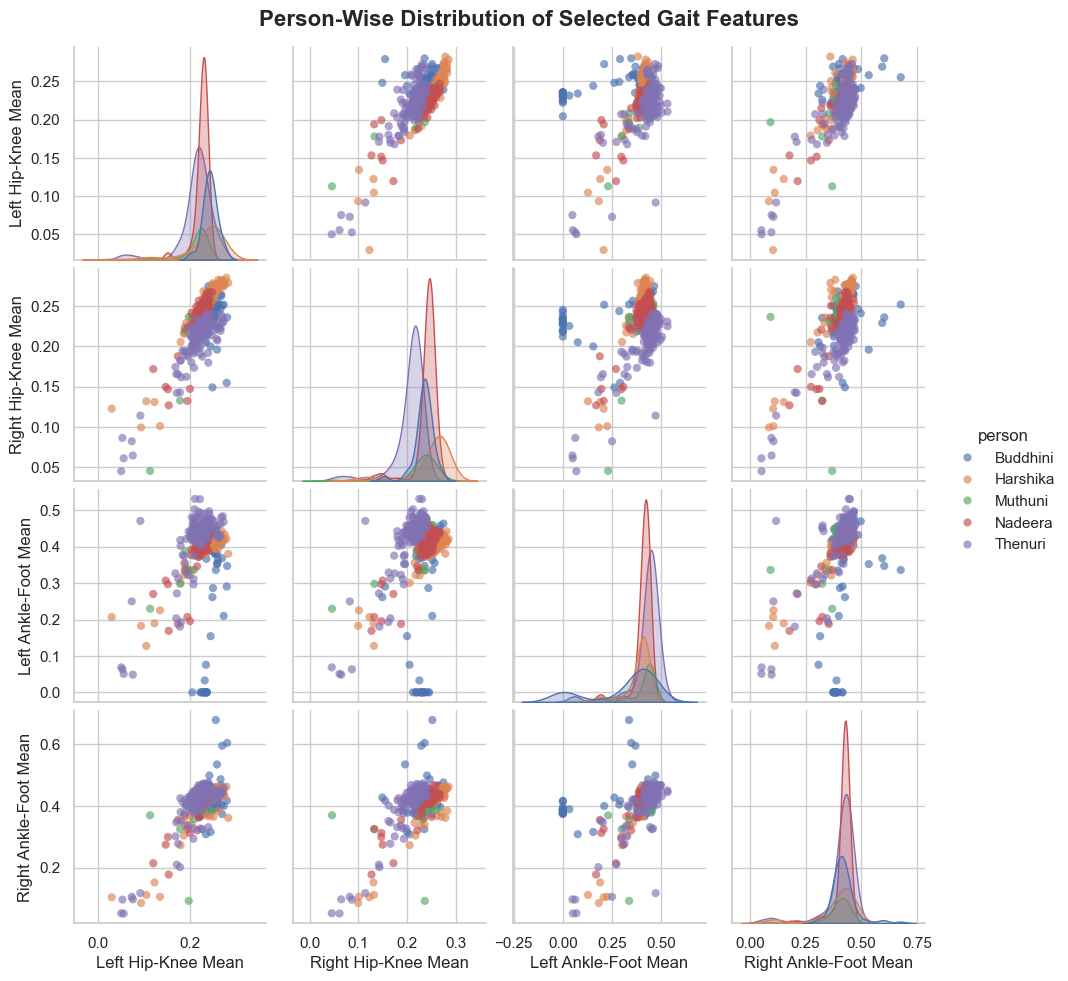

In [ ]:
# CELL 4 — Person-wise pairplot of selected gait features

viz_features = [
    "left_hip_to_knee_original_angle__mean",
    "right_hip_to_knee_original_angle__mean",
    "left_ankle_to_foot_original_angle__mean",
    "right_ankle_to_foot_original_angle__mean"
]

viz_df = df[
    ["person"] + viz_features
].copy()

# Shorter names for cleaner axis labels
viz_df = viz_df.rename(
    columns={
        "left_hip_to_knee_original_angle__mean":
            "Left Hip-Knee Mean",

        "right_hip_to_knee_original_angle__mean":
            "Right Hip-Knee Mean",

        "left_ankle_to_foot_original_angle__mean":
            "Left Ankle-Foot Mean",

        "right_ankle_to_foot_original_angle__mean":
            "Right Ankle-Foot Mean"
    }
)

people_order = sorted(
    viz_df["person"].unique()
)

g = sns.pairplot(
    data=viz_df,
    vars=[
        "Left Hip-Knee Mean",
        "Right Hip-Knee Mean",
        "Left Ankle-Foot Mean",
        "Right Ankle-Foot Mean"
    ],
    hue="person",
    hue_order=people_order,
    diag_kind="kde",
    height=2.4,
    plot_kws={
        "s": 35,
        "alpha": 0.65,
        "edgecolor": "none"
    },
    diag_kws={
        "fill": True,
        "alpha": 0.30
    }
)

g.fig.suptitle(
    "Person-Wise Distribution of Selected Gait Features",
    y=1.02,
    fontsize=16,
    fontweight="bold"
)

g.fig.savefig(
    RESULTS_DIR / "person_gait_feature_pairplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Each dot = one gait cycle.
Each color = one person.

The diagonal plots show how the value of each feature is distributed for Buddhini, Harshika, Muthuni, Nadeera, and Thenuri.

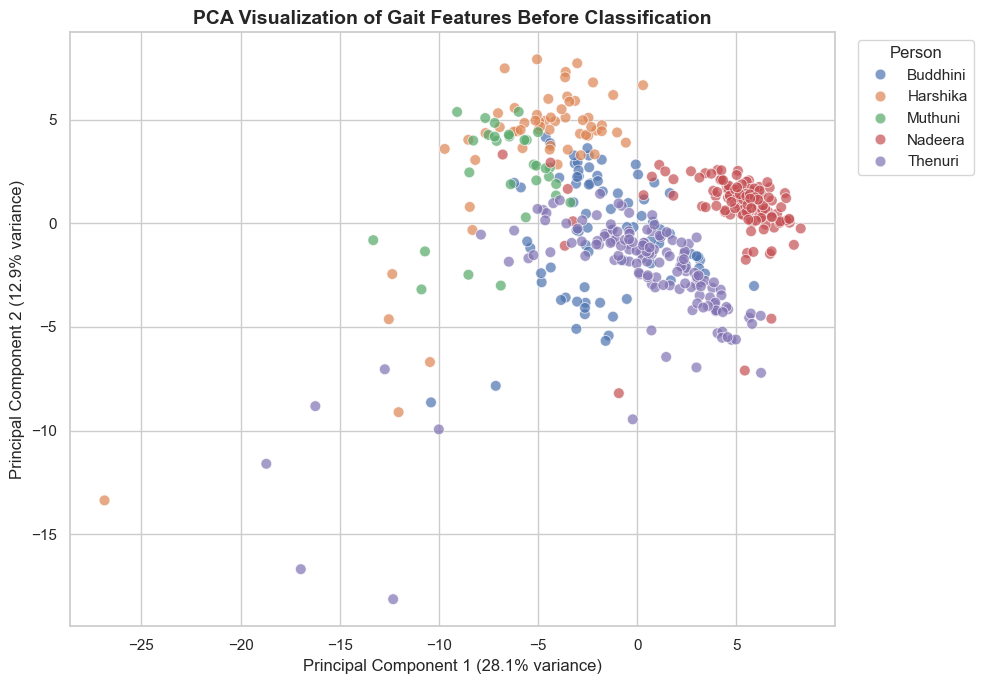

In [ ]:
# CELL 5 — PCA visualization of the complete feature space

X_visualization = df[
    feature_cols
].copy()

# Standardize because the 91 features can have different scales
visualization_scaler = StandardScaler()

X_visualization_scaled = (
    visualization_scaler.fit_transform(
        X_visualization
    )
)

# PCA used only for 2D visualization here
visualization_pca = PCA(
    n_components=2
)

X_visualization_pca = (
    visualization_pca.fit_transform(
        X_visualization_scaled
    )
)

pca_visualization_df = pd.DataFrame({
    "PC1": X_visualization_pca[:, 0],
    "PC2": X_visualization_pca[:, 1],
    "person": df["person"].values
})

pc1_variance = (
    visualization_pca
    .explained_variance_ratio_[0]
    * 100
)

pc2_variance = (
    visualization_pca
    .explained_variance_ratio_[1]
    * 100
)

plt.figure(
    figsize=(10, 7)
)

sns.scatterplot(
    data=pca_visualization_df,
    x="PC1",
    y="PC2",
    hue="person",
    hue_order=people_order,
    s=60,
    alpha=0.70
)

plt.xlabel(
    f"Principal Component 1 "
    f"({pc1_variance:.1f}% variance)"
)

plt.ylabel(
    f"Principal Component 2 "
    f"({pc2_variance:.1f}% variance)"
)

plt.title(
    "PCA Visualization of Gait Features Before Classification",
    fontsize=14,
    fontweight="bold"
)

plt.legend(
    title="Person",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / "person_gait_pca_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# CELL 6 — PCA visualization variance information

visualization_variance = (
    visualization_pca
    .explained_variance_ratio_
    * 100
)

print("PCA VISUALIZATION")
print("-" * 45)

print(
    f"PC1 explained variance : "
    f"{visualization_variance[0]:.2f}%"
)

print(
    f"PC2 explained variance : "
    f"{visualization_variance[1]:.2f}%"
)

print(
    f"Total shown in 2D      : "
    f"{visualization_variance.sum():.2f}%"
)

PCA VISUALIZATION
---------------------------------------------
PC1 explained variance : 28.07%
PC2 explained variance : 12.85%
Total shown in 2D      : 40.92%


## 2. Load Evaluation Results

The saved results from the two model configurations are loaded below.

Model A uses the complete 91-feature representation without dimensionality
reduction.

Model B applies PCA within each training split before classification using
the same Linear SVM configuration.

In [ ]:
# CELL 4 — Load evaluation results

# Model A — No dimensionality reduction
exhaustive_results_df = pd.read_csv(
    RESULTS_DIR / "exhaustive_svm_results.csv"
)

# Model B — PCA dimensionality reduction
pca_results_df = pd.read_csv(
    RESULTS_DIR / "pca_svm_exhaustive_results.csv"
)

# PCA trial-level stability
pca_trial_stability = pd.read_csv(
    RESULTS_DIR / "pca_svm_trial_stability.csv"
)

print("Results loaded successfully.")

print(
    "Model A exhaustive splits:",
    len(exhaustive_results_df)
)

print(
    "Model B exhaustive splits:",
    len(pca_results_df)
)

print(
    "Independent trials:",
    len(pca_trial_stability)
)

Results loaded successfully.
Model A exhaustive splits: 1440
Model B exhaustive splits: 1440
Independent trials: 22


## 3. Model A — Without Dimensionality Reduction

Model A uses all **91 extracted gait features** directly after standardization,
without applying dimensionality reduction.

The model consists of:

**91 features → StandardScaler → Linear SVM**

Evaluation is performed by holding out one complete walking trial from each
participant in every split.

In [ ]:
# CELL 6 — Model A performance

model_a_dimensions = 91

model_a_accuracy = (
    exhaustive_results_df["accuracy"].mean() * 100
)

model_a_balanced_accuracy = (
    exhaustive_results_df["balanced_accuracy"].mean() * 100
)

model_a_macro_f1 = (
    exhaustive_results_df["macro_f1"].mean() * 100
)

print("=" * 55)
print("MODEL A — WITHOUT DIMENSIONALITY REDUCTION")
print("=" * 55)

print(f"Input dimensions       : {model_a_dimensions}")
print(f"Mean accuracy          : {model_a_accuracy:.2f}%")
print(f"Balanced accuracy      : {model_a_balanced_accuracy:.2f}%")
print(f"Macro F1               : {model_a_macro_f1:.2f}%")

MODEL A — WITHOUT DIMENSIONALITY REDUCTION
Input dimensions       : 91
Mean accuracy          : 96.36%
Balanced accuracy      : 95.04%
Macro F1               : 94.82%


In [ ]:
# CELL 7 — Model A exhaustive evaluation summary

model_a_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1"
    ],

    "Mean (%)": [
        exhaustive_results_df["accuracy"].mean() * 100,
        exhaustive_results_df["balanced_accuracy"].mean() * 100,
        exhaustive_results_df["macro_f1"].mean() * 100
    ],

    "Std (%)": [
        exhaustive_results_df["accuracy"].std() * 100,
        exhaustive_results_df["balanced_accuracy"].std() * 100,
        exhaustive_results_df["macro_f1"].std() * 100
    ],

    "Minimum (%)": [
        exhaustive_results_df["accuracy"].min() * 100,
        exhaustive_results_df["balanced_accuracy"].min() * 100,
        exhaustive_results_df["macro_f1"].min() * 100
    ],

    "Maximum (%)": [
        exhaustive_results_df["accuracy"].max() * 100,
        exhaustive_results_df["balanced_accuracy"].max() * 100,
        exhaustive_results_df["macro_f1"].max() * 100
    ]

})

display(model_a_summary.round(2))

,Metric,Mean (%),Std (%),Minimum (%),Maximum (%)
0,Accuracy,96.36,2.18,85.00,100.0
1,Balanced accuracy,95.04,3.16,79.39,100.0
2,Macro F1,94.82,3.22,78.84,100.0


## 3. Model B — PCA Dimensionality Reduction

Model B applies Principal Component Analysis (PCA) before classification.

The model consists of:

**91 features → StandardScaler → PCA → Linear SVM**

PCA retains at least **95% of the variance** in the training data.

To prevent data leakage, both StandardScaler and PCA are fitted only using
the training trials within each evaluation split.

In [ ]:
# CELL 10 — Model B PCA results

model_b_dimensions = (
    pca_results_df["n_components"].mean()
)

model_b_accuracy = (
    pca_results_df["accuracy"].mean() * 100
)

model_b_balanced_accuracy = (
    pca_results_df["balanced_accuracy"].mean() * 100
)

model_b_macro_f1 = (
    pca_results_df["macro_f1"].mean() * 100
)

variance_retained = (
    pca_results_df["explained_variance"].mean()
    * 100
)

dimension_reduction = (
    1 -
    model_b_dimensions / model_a_dimensions
) * 100

accuracy_change = (
    model_b_accuracy -
    model_a_accuracy
)

print("=" * 55)
print("MODEL B — PCA + LINEAR SVM")
print("=" * 55)

print(
    f"Original dimensions    : "
    f"{model_a_dimensions}"
)

print(
    f"Mean PCA dimensions    : "
    f"{model_b_dimensions:.2f}"
)

print(
    f"PCA dimension range    : "
    f"{pca_results_df['n_components'].min()}–"
    f"{pca_results_df['n_components'].max()}"
)

print(
    f"Dimension reduction    : "
    f"{dimension_reduction:.2f}%"
)

print(
    f"Variance retained      : "
    f"{variance_retained:.2f}%"
)

print(
    f"Mean accuracy          : "
    f"{model_b_accuracy:.2f}%"
)

print(
    f"Balanced accuracy      : "
    f"{model_b_balanced_accuracy:.2f}%"
)

print(
    f"Macro F1               : "
    f"{model_b_macro_f1:.2f}%"
)

MODEL B — PCA + LINEAR SVM
Original dimensions    : 91
Mean PCA dimensions    : 26.17
PCA dimension range    : 25–28
Dimension reduction    : 71.24%
Variance retained      : 95.23%
Mean accuracy          : 95.62%
Balanced accuracy      : 93.98%
Macro F1               : 93.81%


In [ ]:
# CELL 11 — Model B exhaustive evaluation summary

model_b_summary = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1"
    ],

    "Mean (%)": [
        pca_results_df["accuracy"].mean() * 100,
        pca_results_df["balanced_accuracy"].mean() * 100,
        pca_results_df["macro_f1"].mean() * 100
    ],

    "Std (%)": [
        pca_results_df["accuracy"].std() * 100,
        pca_results_df["balanced_accuracy"].std() * 100,
        pca_results_df["macro_f1"].std() * 100
    ],

    "Minimum (%)": [
        pca_results_df["accuracy"].min() * 100,
        pca_results_df["balanced_accuracy"].min() * 100,
        pca_results_df["macro_f1"].min() * 100
    ],

    "Maximum (%)": [
        pca_results_df["accuracy"].max() * 100,
        pca_results_df["balanced_accuracy"].max() * 100,
        pca_results_df["macro_f1"].max() * 100
    ]

})

display(
    model_b_summary.round(2)
)

,Metric,Mean (%),Std (%),Minimum (%),Maximum (%)
0,Accuracy,95.62,2.93,81.82,100.0
1,Balanced accuracy,93.98,4.21,75.64,100.0
2,Macro F1,93.81,4.20,74.06,100.0


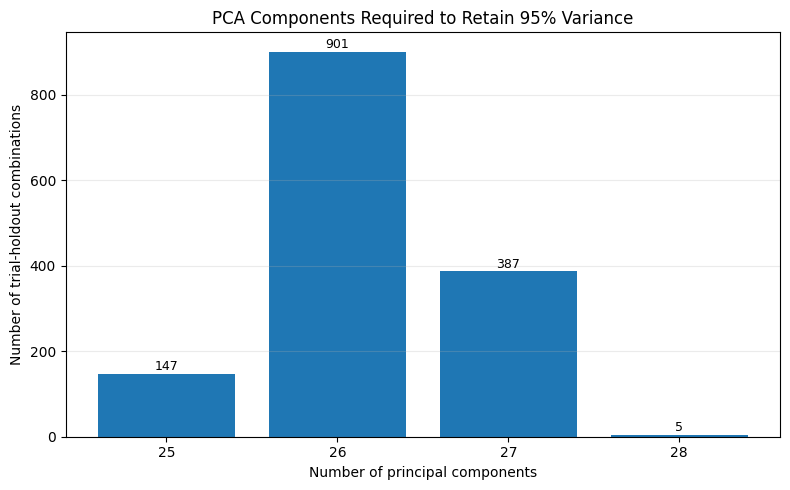

Mean PCA components: 26.17
Range: 25–28
Mean variance retained: 95.23%


In [ ]:
# CELL 12 — PCA components required to retain 95% variance

component_counts = (
    pca_results_df["n_components"]
    .value_counts()
    .sort_index()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    component_counts.index.astype(str),
    component_counts.values
)

ax.set_xlabel(
    "Number of principal components"
)

ax.set_ylabel(
    "Number of trial-holdout combinations"
)

ax.set_title(
    "PCA Components Required to Retain 95% Variance"
)

ax.grid(
    axis="y",
    alpha=0.25
)

for bar, value in zip(
    bars,
    component_counts.values
):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 8,
        str(value),
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

print(
    f"Mean PCA components: "
    f"{model_b_dimensions:.2f}"
)

print(
    f"Range: "
    f"{pca_results_df['n_components'].min()}–"
    f"{pca_results_df['n_components'].max()}"
)

print(
    f"Mean variance retained: "
    f"{variance_retained:.2f}%"
)

## 4. Comparison With and Without Dimensionality Reduction

The following analysis directly compares the two Linear SVM configurations
using the same exhaustive trial-grouped evaluation protocol.

In [ ]:
# CELL 15 — Model comparison table

model_comparison = pd.DataFrame({

    "Model": [
        "Without dimensionality reduction",
        "PCA dimensionality reduction"
    ],

    "Mean dimensions": [
        model_a_dimensions,
        model_b_dimensions
    ],

    "Dimension reduction (%)": [
        0.00,
        dimension_reduction
    ],

    "Variance retained (%)": [
        100.00,
        variance_retained
    ],

    "Accuracy (%)": [
        model_a_accuracy,
        model_b_accuracy
    ],

    "Balanced accuracy (%)": [
        model_a_balanced_accuracy,
        model_b_balanced_accuracy
    ],

    "Macro F1 (%)": [
        model_a_macro_f1,
        model_b_macro_f1
    ]

})

display(
    model_comparison.round(2)
)

,Model,Mean dimensions,Dimension reduction (%),Variance retained (%),Accuracy (%),Balanced accuracy (%),Macro F1 (%)
0,Without dimensionality reduction,91.00,0.00,100.00,96.36,95.04,94.82
1,PCA dimensionality reduction,26.17,71.24,95.23,95.62,93.98,93.81


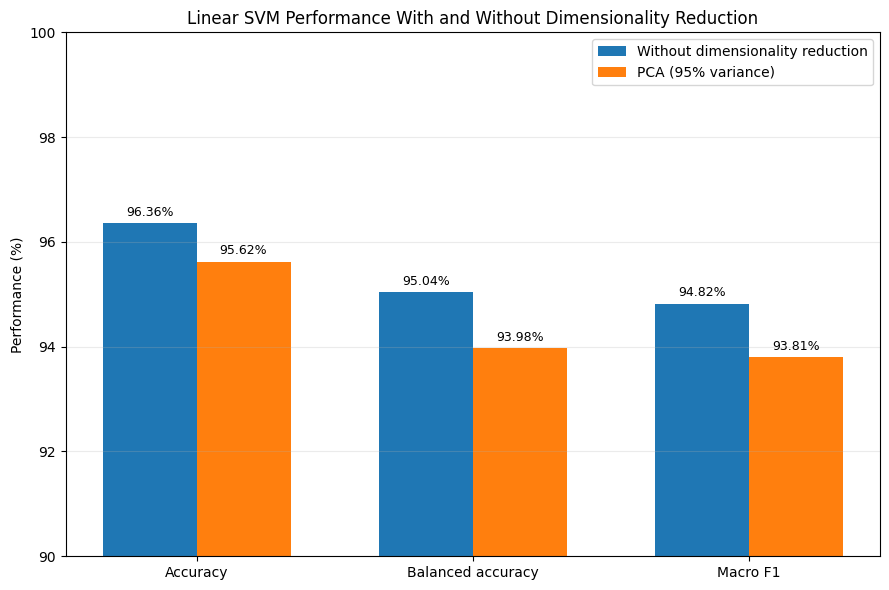

In [ ]:
# CELL 16 — Performance comparison

metrics = [
    "Accuracy",
    "Balanced accuracy",
    "Macro F1"
]

without_pca = [
    model_a_accuracy,
    model_a_balanced_accuracy,
    model_a_macro_f1
]

with_pca = [
    model_b_accuracy,
    model_b_balanced_accuracy,
    model_b_macro_f1
]

x = np.arange(
    len(metrics)
)

width = 0.34

fig, ax = plt.subplots(
    figsize=(9, 6)
)

bars1 = ax.bar(
    x - width/2,
    without_pca,
    width,
    label="Without dimensionality reduction"
)

bars2 = ax.bar(
    x + width/2,
    with_pca,
    width,
    label="PCA (95% variance)"
)

ax.set_ylabel(
    "Performance (%)"
)

ax.set_title(
    "Linear SVM Performance With and Without "
    "Dimensionality Reduction"
)

ax.set_xticks(x)

ax.set_xticklabels(
    metrics
)

ax.set_ylim(
    90,
    100
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

ax.bar_label(
    bars1,
    fmt="%.2f%%",
    padding=3,
    fontsize=9
)

ax.bar_label(
    bars2,
    fmt="%.2f%%",
    padding=3,
    fontsize=9
)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 18 — Effect of dimensionality reduction

comparison_changes = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Balanced accuracy",
        "Macro F1"
    ],

    "Without PCA (%)": [
        model_a_accuracy,
        model_a_balanced_accuracy,
        model_a_macro_f1
    ],

    "With PCA (%)": [
        model_b_accuracy,
        model_b_balanced_accuracy,
        model_b_macro_f1
    ]
})

comparison_changes["Change (percentage points)"] = (
    comparison_changes["With PCA (%)"]
    -
    comparison_changes["Without PCA (%)"]
)

display(
    comparison_changes.round(2)
)

,Metric,Without PCA (%),With PCA (%),Change (percentage points)
0,Accuracy,96.36,95.62,-0.73
1,Balanced accuracy,95.04,93.98,-1.06
2,Macro F1,94.82,93.81,-1.02


## 5. Trial-Level Robustness of the PCA Model

Trial-level predictions are obtained using majority voting across the gait
cycles belonging to each held-out walking trial.

This analysis examines whether individual trials remain consistently
identifiable across different training-trial configurations.

In [ ]:
# CELL 20 — Trial-level PCA stability

display(
    pca_trial_stability[
        [
            "person",
            "trial",
            "correct_count",
            "total_tests",
            "correct_pct"
        ]
    ].round(2)
)

,person,trial,correct_count,total_tests,correct_pct
0,Buddhini,1,240,240,100.00
1,Buddhini,2,240,240,100.00
2,Buddhini,3,240,240,100.00
3,Buddhini,4,240,240,100.00
4,Buddhini,7,199,240,82.92
5,Buddhini,9,240,240,100.00
6,Harshika,1,288,288,100.00
7,Harshika,2,288,288,100.00
8,Harshika,3,288,288,100.00
9,Harshika,4,288,288,100.00


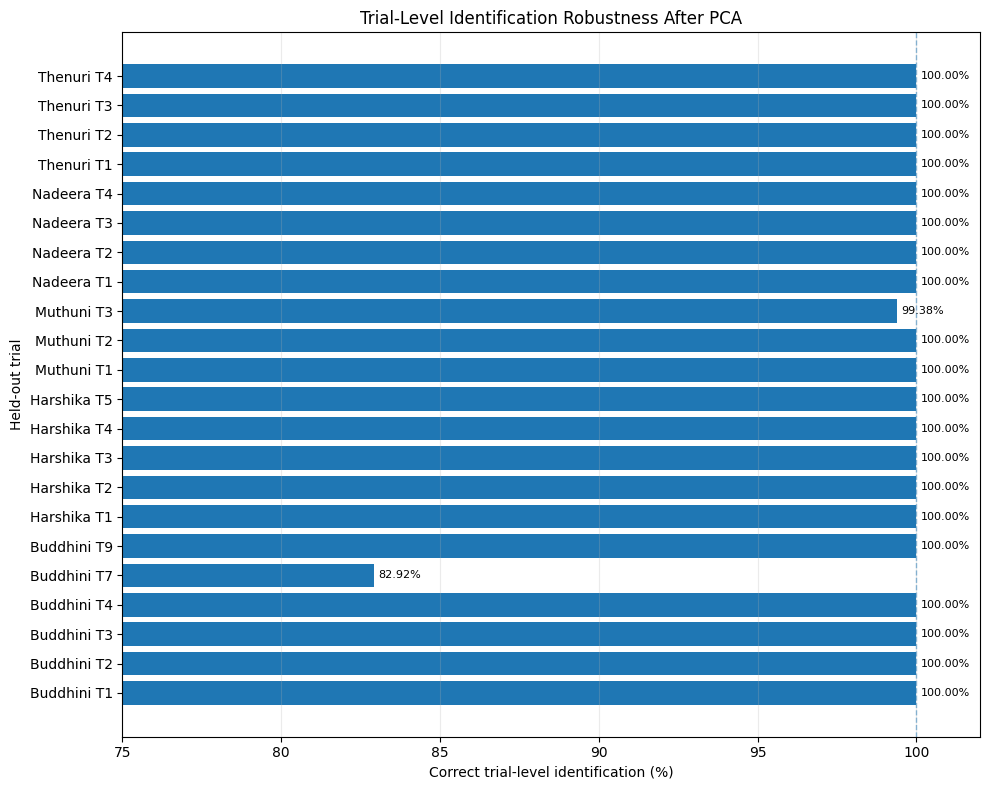

In [ ]:
# CELL 21 — Trial-level robustness plot

trial_plot = (
    pca_trial_stability
    .copy()
)

trial_plot["Trial"] = (
    trial_plot["person"].astype(str)
    + " T"
    + trial_plot["trial"].astype(str)
)

trial_plot = (
    trial_plot
    .sort_values(
        ["person", "trial"]
    )
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

bars = ax.barh(
    trial_plot["Trial"],
    trial_plot["correct_pct"]
)

ax.set_xlabel(
    "Correct trial-level identification (%)"
)

ax.set_ylabel(
    "Held-out trial"
)

ax.set_title(
    "Trial-Level Identification Robustness "
    "After PCA"
)

ax.set_xlim(
    75,
    102
)

ax.axvline(
    100,
    linestyle="--",
    linewidth=1,
    alpha=0.5
)

ax.grid(
    axis="x",
    alpha=0.25
)

for bar, value in zip(
    bars,
    trial_plot["correct_pct"]
):

    ax.text(
        value + 0.15,
        bar.get_y()
        + bar.get_height()/2,
        f"{value:.2f}%",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [ ]:
# CELL 22 — Identify trials below 100% stability

less_than_perfect = (
    pca_trial_stability[
        pca_trial_stability["correct_pct"] < 100
    ]
    .sort_values("correct_pct")
)

print(
    "Trials with less than 100% "
    "identification stability:"
)

display(
    less_than_perfect.round(2)
)

Trials with less than 100% identification stability:


,person,trial,correct_count,total_tests,correct_pct
4,Buddhini,7,199,240,82.92
13,Muthuni,3,477,480,99.38


## 6. Supporting Feature-Ablation Analysis

Additional experiments were performed to examine how different groups of
the original gait features contribute to identification performance.

These experiments are supporting analyses and are separate from the PCA
dimensionality-reduction comparison.

In [ ]:
# CELL 24 — Feature-ablation results

feature_comparison = pd.DataFrame({

    "Feature set": [
        "All angles + duration\n(91 features)",
        "All angle features\n(90 features)",
        "Mean / min / max\n(54 features)",
        "Std / range\n(36 features)"
    ],

    "Accuracy": [
        96.36,
        95.89,
        95.15,
        84.50
    ],

    "Balanced accuracy": [
        95.04,
        94.58,
        93.72,
        83.77
    ],

    "Macro F1": [
        94.82,
        94.33,
        93.43,
        82.02
    ]
})

display(
    feature_comparison
)

,Feature set,Accuracy,Balanced accuracy,Macro F1
0,All angles + duration\n(91 features),96.36,95.04,94.82
1,All angle features\n(90 features),95.89,94.58,94.33
2,Mean / min / max\n(54 features),95.15,93.72,93.43
3,Std / range\n(36 features),84.50,83.77,82.02


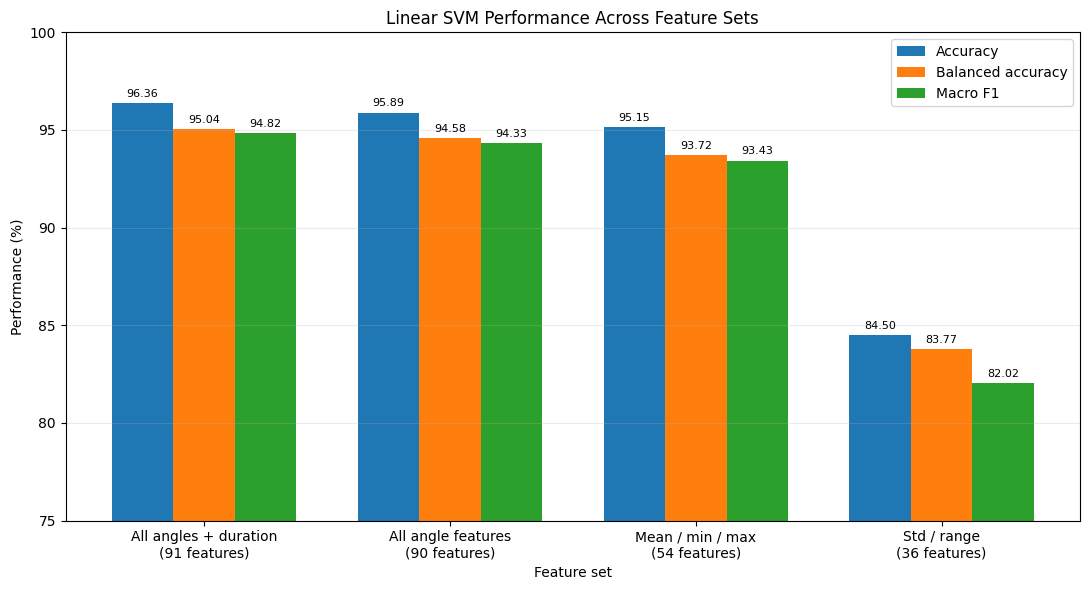

In [ ]:
# CELL 25 — Feature-ablation comparison

x = np.arange(
    len(feature_comparison)
)

width = 0.25

fig, ax = plt.subplots(
    figsize=(11, 6)
)

b1 = ax.bar(
    x - width,
    feature_comparison["Accuracy"],
    width,
    label="Accuracy"
)

b2 = ax.bar(
    x,
    feature_comparison["Balanced accuracy"],
    width,
    label="Balanced accuracy"
)

b3 = ax.bar(
    x + width,
    feature_comparison["Macro F1"],
    width,
    label="Macro F1"
)

ax.set_ylabel(
    "Performance (%)"
)

ax.set_xlabel(
    "Feature set"
)

ax.set_title(
    "Linear SVM Performance Across Feature Sets"
)

ax.set_xticks(x)

ax.set_xticklabels(
    feature_comparison["Feature set"]
)

ax.set_ylim(
    75,
    100
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

ax.bar_label(
    b1,
    fmt="%.2f",
    padding=3,
    fontsize=8
)

ax.bar_label(
    b2,
    fmt="%.2f",
    padding=3,
    fontsize=8
)

ax.bar_label(
    b3,
    fmt="%.2f",
    padding=3,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 26 — Feature-ablation performance changes

baseline_acc = (
    feature_comparison.loc[
        0,
        "Accuracy"
    ]
)

baseline_bal = (
    feature_comparison.loc[
        0,
        "Balanced accuracy"
    ]
)

baseline_f1 = (
    feature_comparison.loc[
        0,
        "Macro F1"
    ]
)

ablation_loss = (
    feature_comparison.copy()
)

ablation_loss["Accuracy change"] = (
    ablation_loss["Accuracy"]
    - baseline_acc
)

ablation_loss[
    "Balanced accuracy change"
] = (
    ablation_loss["Balanced accuracy"]
    - baseline_bal
)

ablation_loss["Macro F1 change"] = (
    ablation_loss["Macro F1"]
    - baseline_f1
)

display(
    ablation_loss.round(2)
)

,Feature set,Accuracy,Balanced accuracy,Macro F1,Accuracy change,Balanced accuracy change,Macro F1 change
0,All angles + duration\n(91 features),96.36,95.04,94.82,0.00,0.00,0.00
1,All angle features\n(90 features),95.89,94.58,94.33,-0.47,-0.46,-0.49
2,Mean / min / max\n(54 features),95.15,93.72,93.43,-1.21,-1.32,-1.39
3,Std / range\n(36 features),84.50,83.77,82.02,-11.86,-11.27,-12.80


In [ ]:
# CELL 2 — Load exhaustive evaluation results

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exhaustive_results_df = pd.read_csv(
    RESULTS_DIR / "exhaustive_svm_results.csv"
)

print("Loaded exhaustive results.")
print("Number of trial-holdout combinations:", len(exhaustive_results_df))

display(exhaustive_results_df.head())

print("\nPerformance summary:")
display(
    exhaustive_results_df[
        ["accuracy", "balanced_accuracy", "macro_f1"]
    ].describe().round(4)
)

Loaded exhaustive results.
Number of trial-holdout combinations: 1440


,split_id,accuracy,balanced_accuracy,macro_f1,test_cycles
0,1,0.977528,0.960000,0.963376,89
1,2,0.971429,0.960000,0.968022,70
2,3,0.968085,0.955455,0.951553,94
3,4,0.967391,0.955238,0.952308,92
4,5,0.963964,0.950476,0.956025,111



Performance summary:


,accuracy,balanced_accuracy,macro_f1
count,1440.0000,1440.0000,1440.0000
mean,0.9636,0.9504,0.9482
std,0.0218,0.0316,0.0322
min,0.8500,0.7939,0.7884
25%,0.9514,0.9330,0.9313
50%,0.9663,0.9511,0.9536
75%,0.9781,0.9730,0.9699
max,1.0000,1.0000,1.0000


## 7. Final Findings

In [ ]:
# CELL 28 — Final findings

perfect_trials = (
    pca_trial_stability["correct_pct"]
    == 100
).sum()

total_trials = len(
    pca_trial_stability
)

print("=" * 72)
print("FINAL FINDINGS")
print("=" * 72)

print(
    f"""
MODEL A — WITHOUT DIMENSIONALITY REDUCTION

The Linear SVM using all {model_a_dimensions} features achieved:

• Mean accuracy          : {model_a_accuracy:.2f}%
• Balanced accuracy      : {model_a_balanced_accuracy:.2f}%
• Macro F1               : {model_a_macro_f1:.2f}%


MODEL B — PCA DIMENSIONALITY REDUCTION

PCA reduced the original {model_a_dimensions}-dimensional
feature representation to an average of
{model_b_dimensions:.2f} principal components.

• PCA component range    : {pca_results_df["n_components"].min()}–{pca_results_df["n_components"].max()}
• Dimension reduction    : {dimension_reduction:.2f}%
• Variance retained      : {variance_retained:.2f}%

The PCA + Linear SVM achieved:

• Mean accuracy          : {model_b_accuracy:.2f}%
• Balanced accuracy      : {model_b_balanced_accuracy:.2f}%
• Macro F1               : {model_b_macro_f1:.2f}%


MODEL COMPARISON

Mean accuracy changed from {model_a_accuracy:.2f}%
without dimensionality reduction to
{model_b_accuracy:.2f}% with PCA.

Accuracy difference:
{accuracy_change:.2f} percentage points.

Therefore, PCA reduced the feature-space dimensionality
by approximately {dimension_reduction:.2f}% while preserving
most of the classification performance.


TRIAL-LEVEL ROBUSTNESS

{perfect_trials}/{total_trials} held-out trials achieved
100% trial-level identification stability with PCA.
"""
)

FINAL FINDINGS

MODEL A — WITHOUT DIMENSIONALITY REDUCTION

The Linear SVM using all 91 features achieved:

• Mean accuracy          : 96.36%
• Balanced accuracy      : 95.04%
• Macro F1               : 94.82%


MODEL B — PCA DIMENSIONALITY REDUCTION

PCA reduced the original 91-dimensional
feature representation to an average of
26.17 principal components.

• PCA component range    : 25–28
• Dimension reduction    : 71.24%
• Variance retained      : 95.23%

The PCA + Linear SVM achieved:

• Mean accuracy          : 95.62%
• Balanced accuracy      : 93.98%
• Macro F1               : 93.81%


MODEL COMPARISON

Mean accuracy changed from 96.36%
without dimensionality reduction to
95.62% with PCA.

Accuracy difference:
-0.73 percentage points.

Therefore, PCA reduced the feature-space dimensionality
by approximately 71.24% while preserving
most of the classification performance.


TRIAL-LEVEL ROBUSTNESS

20/22 held-out trials achieved
100% trial-level identification stability with PCA.



### Overall Result

Without dimensionality reduction, the 91-feature Linear SVM achieved
approximately **96.36% mean cycle-level accuracy** across the exhaustive
trial-grouped evaluations.

With PCA dimensionality reduction, the representation was reduced from
91 features to an average of approximately **26 principal components**,
corresponding to about a **71% reduction in dimensionality**, while retaining
approximately **95% of the variance**.

The PCA + Linear SVM achieved approximately **95.62% mean cycle-level
accuracy**, representing only about a **0.74 percentage-point decrease**
relative to the model using the full feature representation.

These results indicate that, within the evaluated dataset, PCA provides a
substantially more compact feature representation while preserving most of
the person-identification performance.

In [ ]:
# CELL 30 — Save final result tables

model_a_summary.to_csv(
    RESULTS_DIR / "final_model_a_summary.csv",
    index=False
)

model_b_summary.to_csv(
    RESULTS_DIR / "final_model_b_pca_summary.csv",
    index=False
)

model_comparison.to_csv(
    RESULTS_DIR / "final_modelA_vs_modelB_comparison.csv",
    index=False
)

comparison_changes.to_csv(
    RESULTS_DIR / "final_model_performance_changes.csv",
    index=False
)

pca_trial_stability.to_csv(
    RESULTS_DIR / "final_pca_trial_stability.csv",
    index=False
)

feature_comparison.to_csv(
    RESULTS_DIR / "final_feature_comparison.csv",
    index=False
)

ablation_loss.to_csv(
    RESULTS_DIR / "final_feature_ablation_loss.csv",
    index=False
)

print(
    "All final result tables saved successfully."
)

All final result tables saved successfully.


## Final Interpretation

The results show that the gait features we extracted can identify the five participants quite well, even when complete walking trials are kept separate for testing. The model without dimensionality reduction performed the best, achieving 96.36% mean accuracy using all 91 features.

After applying PCA, the number of features was reduced from 91 to about 26 components, which is around a 71% reduction. Even with this large reduction, the accuracy only dropped slightly to 95.62%. This suggests that many of the original 91 features contain similar or overlapping information, so PCA can represent most of that information using a much smaller set of components.
The small decrease in accuracy after PCA also makes sense. PCA tries to keep the information that explains the most variation in the data, but it does not specifically know which information is important for identifying a person. Therefore, PCA may remove some small but useful differences between people's walking patterns.

The feature experiments also showed that mean, minimum, and maximum angle values are particularly informative. Using only these features still gave 95.15% accuracy, while using only standard deviation and range reduced accuracy to 84.50%.    Pasted markdown This suggests that a person's typical joint-angle values and their movement extremes contain more identifying information than variation alone.

Overall, the full 91 feature model gives the best performance, while PCA gives almost the same performance using far fewer dimensions. So there is a clear trade-off: the original features are preferable when maximum accuracy is the main goal, while PCA is useful when a smaller and more compact feature representation is preferred.